In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
CHART_DIR = Path("../reports/charts")
CHART_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

In [23]:
fund_master = pd.read_csv(PROCESSED_DIR / "01_fund_master_cleaned.csv")
nav_history = pd.read_csv(PROCESSED_DIR / "02_nav_history_cleaned.csv")
aum = pd.read_csv(PROCESSED_DIR / "03_aum_by_fund_house_cleaned.csv")
sip = pd.read_csv(PROCESSED_DIR / "04_monthly_sip_inflows_cleaned.csv")
category_inflows = pd.read_csv(PROCESSED_DIR / "05_category_inflows_cleaned.csv")
folio = pd.read_csv(PROCESSED_DIR / "06_industry_folio_count_cleaned.csv")
performance = pd.read_csv(PROCESSED_DIR / "07_scheme_performance_cleaned.csv")
transactions = pd.read_csv(PROCESSED_DIR / "08_investor_transactions_cleaned.csv")
holdings = pd.read_csv(PROCESSED_DIR / "09_portfolio_holdings_cleaned.csv")
benchmarks = pd.read_csv(PROCESSED_DIR / "10_benchmark_indices_cleaned.csv")

nav_history["date"] = pd.to_datetime(nav_history["date"])
aum["date"] = pd.to_datetime(aum["date"])
sip["month"] = pd.to_datetime(sip["month"])
category_inflows["month"] = pd.to_datetime(category_inflows["month"])
folio["month"] = pd.to_datetime(folio["month"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
holdings["portfolio_date"] = pd.to_datetime(holdings["portfolio_date"])
benchmarks["date"] = pd.to_datetime(benchmarks["date"])

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [24]:
# Dataset Overview
datasets = {
    "fund_master": fund_master,
    "nav_history": nav_history,
    "aum": aum,
    "sip": sip,
    "category_inflows": category_inflows,
    "folio": folio,
    "performance": performance,
    "transactions": transactions,
    "holdings": holdings,
    "benchmarks": benchmarks
}

for name, df in datasets.items():
    print("=" * 80)
    print(name)
    print("Shape:", df.shape)
    print(df.head())

fund_master
Shape: (40, 15)
   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_sip_a

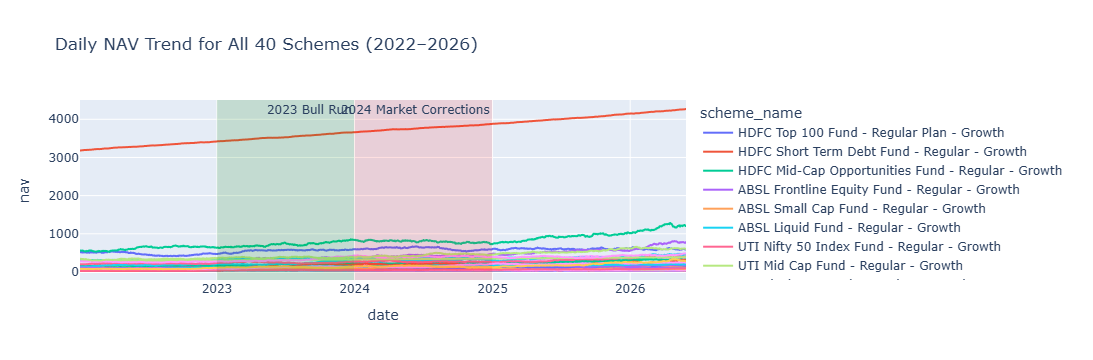

In [25]:
# NAV Trend
nav_2022_2026 = nav_history[
    (nav_history["date"] >= "2022-01-01") &
    (nav_history["date"] <= "2026-12-31")
].copy()

nav_with_names = nav_2022_2026.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

fig = px.line(
    nav_with_names,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend for All 40 Schemes (2022–2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.12,
    line_width=0,
    annotation_text="2024 Market Corrections"
)

fig.show()
fig.write_html(CHART_DIR / "01_nav_trend_all_40_schemes.html")

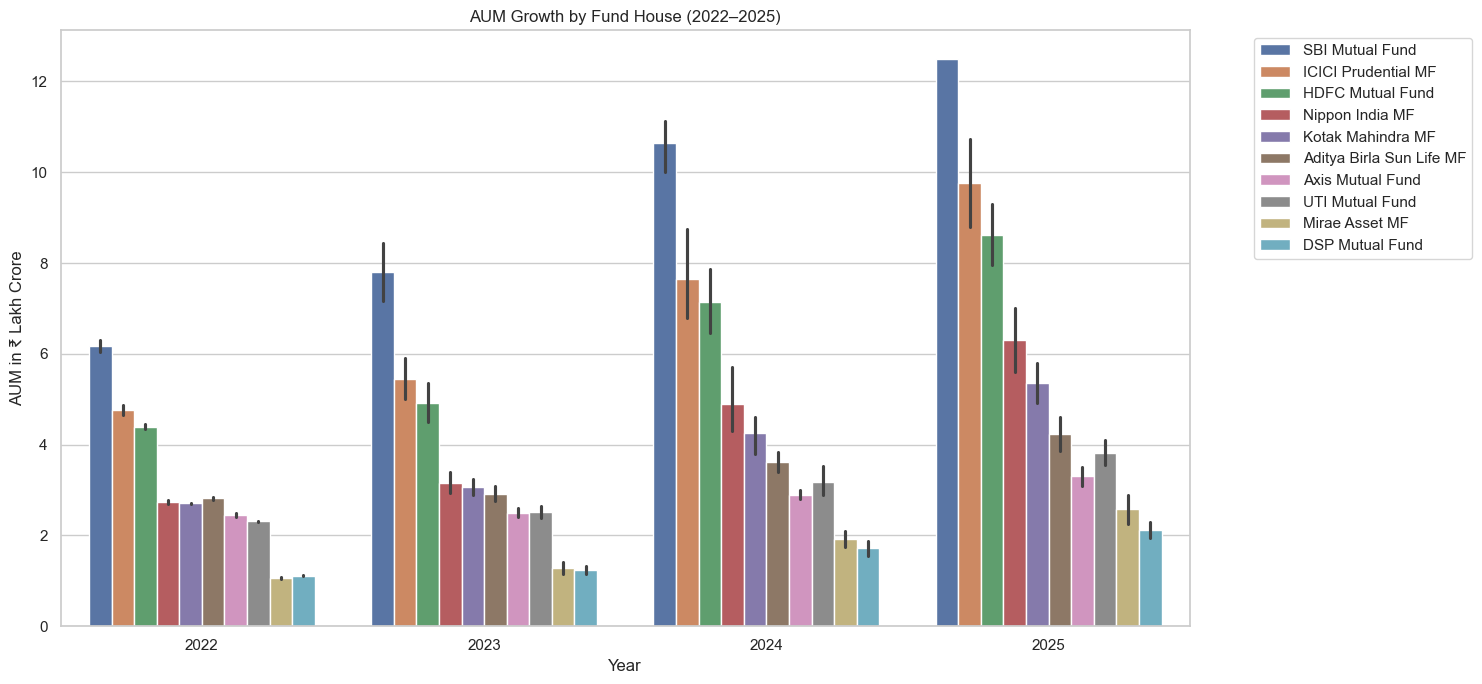

In [26]:
# AUM Growth by Fund House
aum["year"] = aum["date"].dt.year

aum_yearly = aum[
    (aum["year"] >= 2022) &
    (aum["year"] <= 2025)
].copy()

plt.figure(figsize=(15, 7))
sns.barplot(
    data=aum_yearly,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM in ₹ Lakh Crore")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(CHART_DIR / "02_aum_growth_by_fund_house.png", dpi=300)
plt.show()

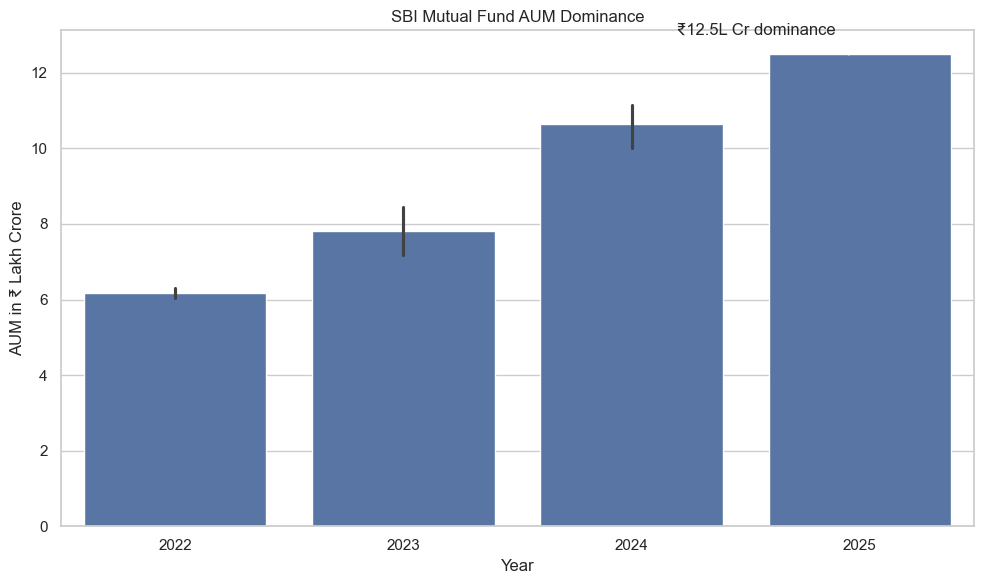

In [27]:
# Highlight SBI AUM Dominance
sbi_aum = aum_yearly[aum_yearly["fund_house"] == "SBI Mutual Fund"]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=sbi_aum,
    x="year",
    y="aum_lakh_crore"
)

plt.title("SBI Mutual Fund AUM Dominance")
plt.xlabel("Year")
plt.ylabel("AUM in ₹ Lakh Crore")

plt.annotate(
    "₹12.5L Cr dominance",
    xy=(3, 12.5),
    xytext=(2.2, 13),
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()
plt.savefig(CHART_DIR / "03_sbi_aum_dominance.png", dpi=300)
plt.show()

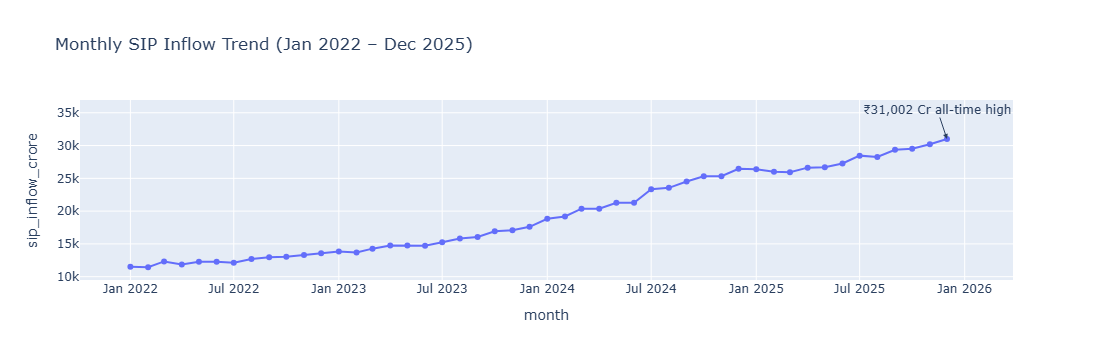

In [28]:
# Monthly SIP Inflow Trend
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)"
)

fig.add_annotation(
    x=pd.to_datetime("2025-12-01"),
    y=31002,
    text="₹31,002 Cr all-time high",
    showarrow=True,
    arrowhead=2
)

fig.show()
fig.write_html(CHART_DIR / "04_monthly_sip_inflow_trend.html")

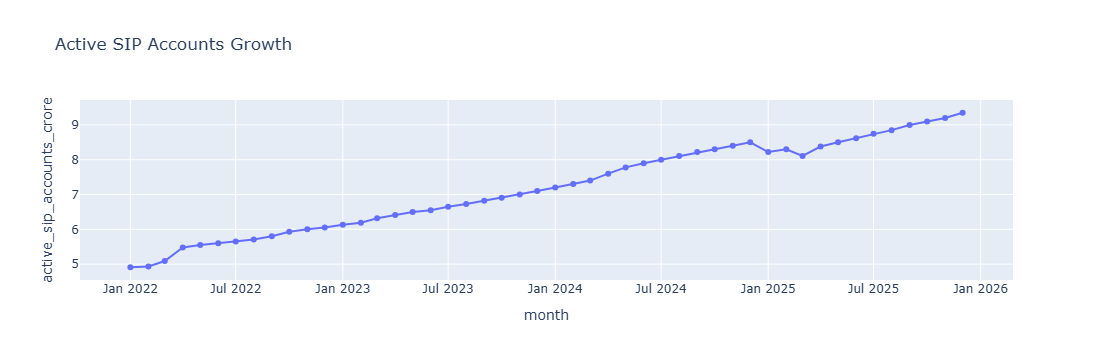

In [29]:
# Active SIP Account Trend
fig = px.line(
    sip,
    x="month",
    y="active_sip_accounts_crore",
    markers=True,
    title="Active SIP Accounts Growth"
)

fig.show()
fig.write_html(CHART_DIR / "05_active_sip_accounts_growth.html")

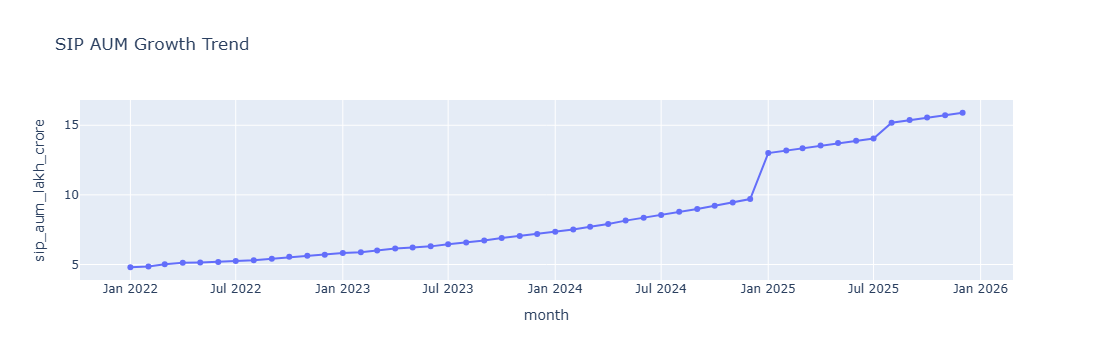

In [30]:
# SIP AUM Trend
fig = px.line(
    sip,
    x="month",
    y="sip_aum_lakh_crore",
    markers=True,
    title="SIP AUM Growth Trend"
)

fig.show()
fig.write_html(CHART_DIR / "06_sip_aum_growth.html")

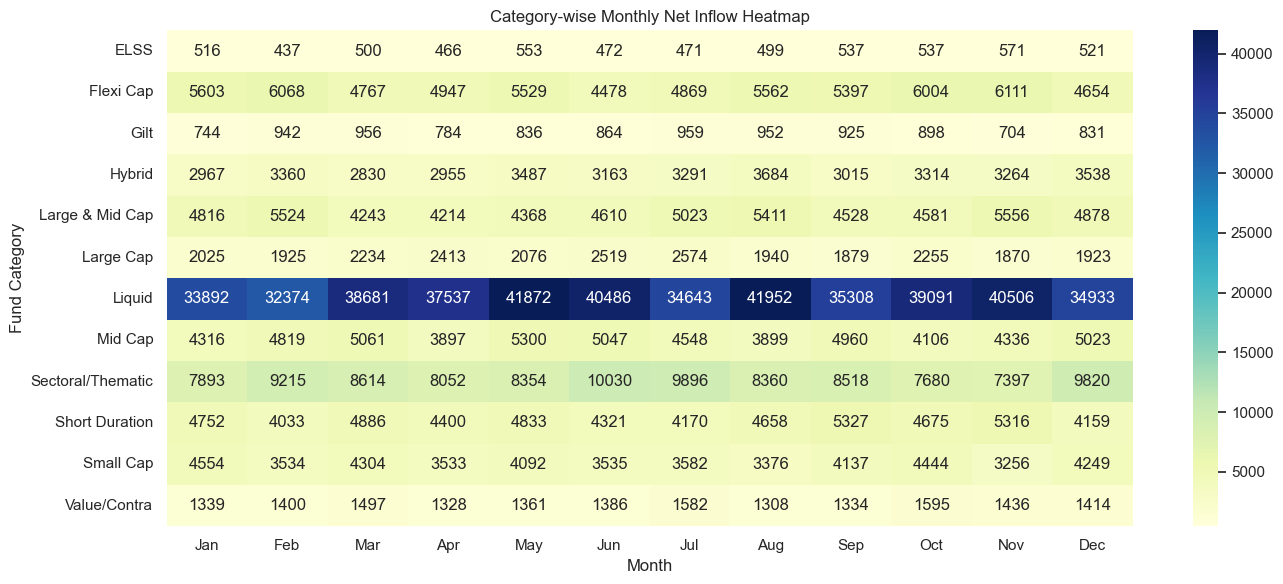

In [31]:
# Category Inflow Heatmap
category_inflows["month_name"] = category_inflows["month"].dt.strftime("%b")
category_inflows["month_num"] = category_inflows["month"].dt.month

heatmap_data = category_inflows.pivot_table(
    index="category",
    columns="month_name",
    values="net_inflow_crore",
    aggfunc="sum"
)

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

heatmap_data = heatmap_data[month_order]

plt.figure(figsize=(14, 6))
sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Category-wise Monthly Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.tight_layout()
plt.savefig(CHART_DIR / "07_category_inflow_heatmap.png", dpi=300)
plt.show()

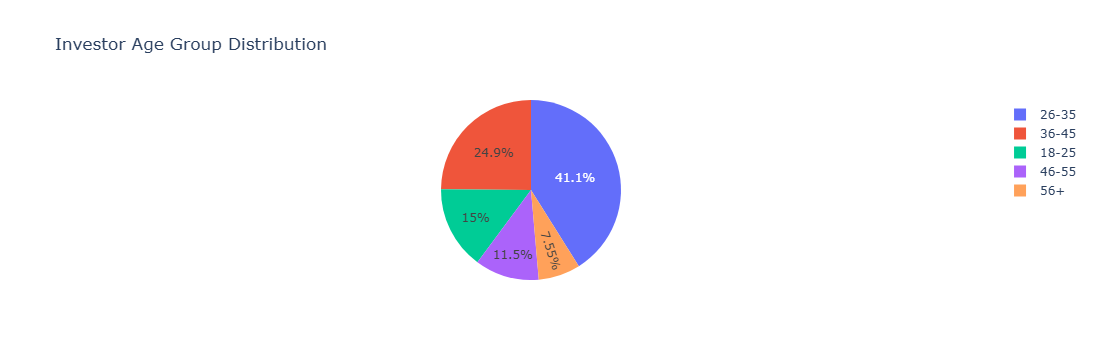

In [32]:
# Age Group Distribution
age_counts = transactions["age_group"].value_counts().reset_index()
age_counts.columns = ["age_group", "count"]

fig = px.pie(
    age_counts,
    names="age_group",
    values="count",
    title="Investor Age Group Distribution"
)

fig.show()
fig.write_html(CHART_DIR / "08_age_group_distribution.html")

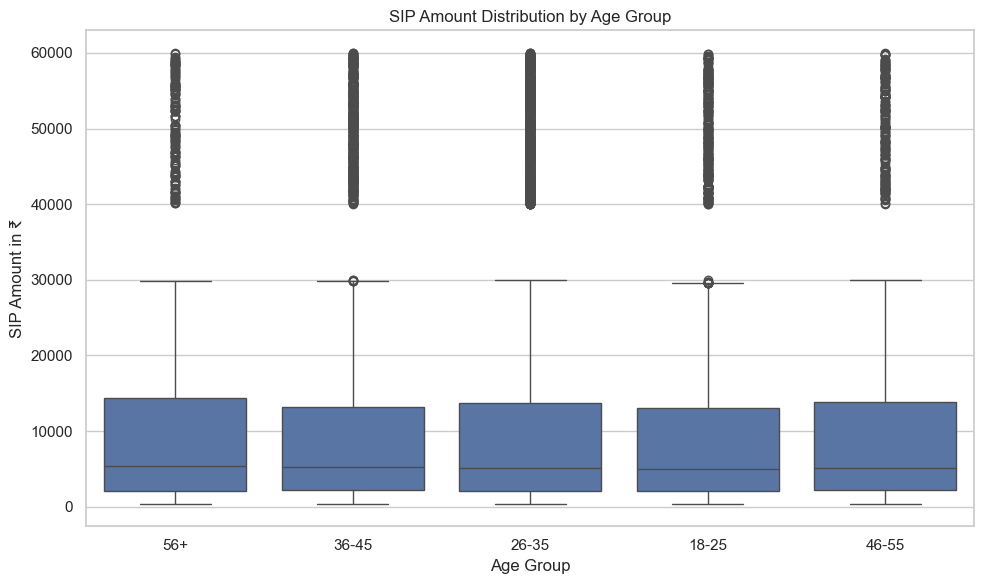

In [33]:
# SIP Amt. Box Plot using Age Grp
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount in ₹")
plt.tight_layout()
plt.savefig(CHART_DIR / "09_sip_amount_by_age_group.png", dpi=300)
plt.show()

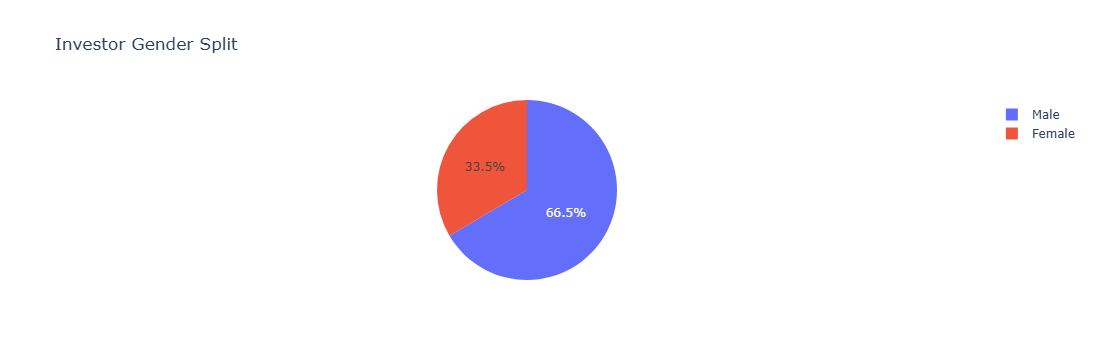

In [34]:
# Gender Split
gender_counts = transactions["gender"].value_counts().reset_index()
gender_counts.columns = ["gender", "count"]

fig = px.pie(
    gender_counts,
    names="gender",
    values="count",
    title="Investor Gender Split"
)

fig.show()
fig.write_html(CHART_DIR / "10_gender_split.html")

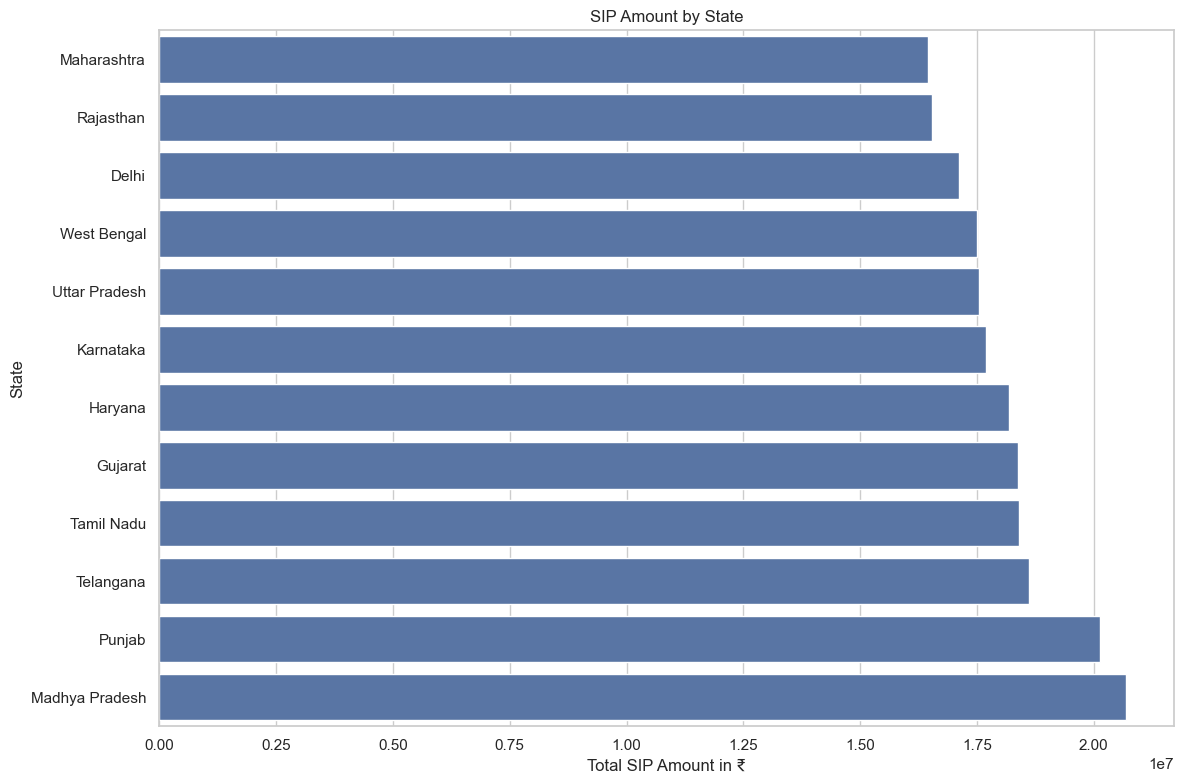

In [35]:
# SIP Amt. by State
state_sip = sip_transactions.groupby("state")["amount_inr"].sum().reset_index()
state_sip = state_sip.sort_values("amount_inr", ascending=True)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=state_sip,
    x="amount_inr",
    y="state"
)

plt.title("SIP Amount by State")
plt.xlabel("Total SIP Amount in ₹")
plt.ylabel("State")
plt.tight_layout()
plt.savefig(CHART_DIR / "11_sip_amount_by_state.png", dpi=300)
plt.show()

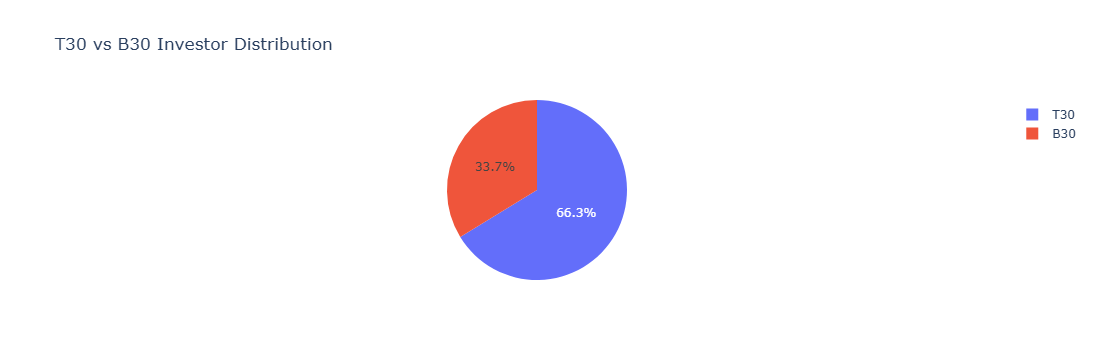

In [36]:
# T30 vs B30 city tier pie chart
city_tier_counts = transactions["city_tier"].value_counts().reset_index()
city_tier_counts.columns = ["city_tier", "count"]

fig = px.pie(
    city_tier_counts,
    names="city_tier",
    values="count",
    title="T30 vs B30 Investor Distribution"
)

fig.show()
fig.write_html(CHART_DIR / "12_t30_b30_city_tier.html")

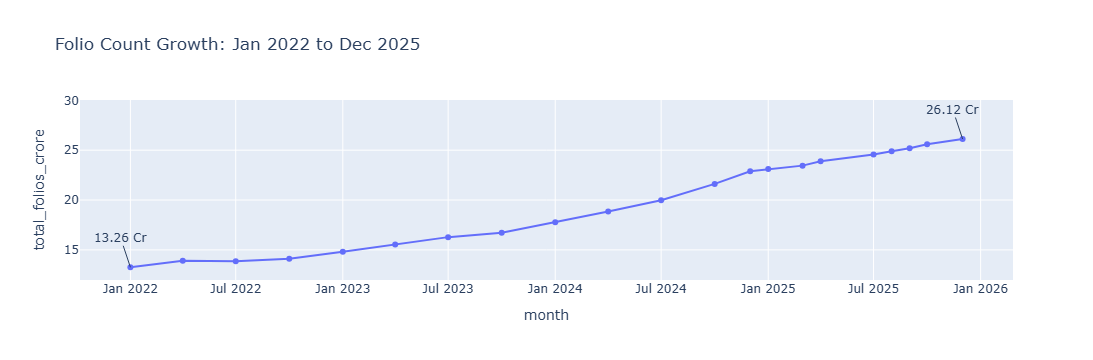

In [37]:
# Folio Count Growth
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Folio Count Growth: Jan 2022 to Dec 2025"
)

fig.add_annotation(
    x=pd.to_datetime("2022-01-01"),
    y=13.26,
    text="13.26 Cr",
    showarrow=True
)

fig.add_annotation(
    x=pd.to_datetime("2025-12-01"),
    y=26.12,
    text="26.12 Cr",
    showarrow=True
)

fig.show()
fig.write_html(CHART_DIR / "13_folio_count_growth.html")

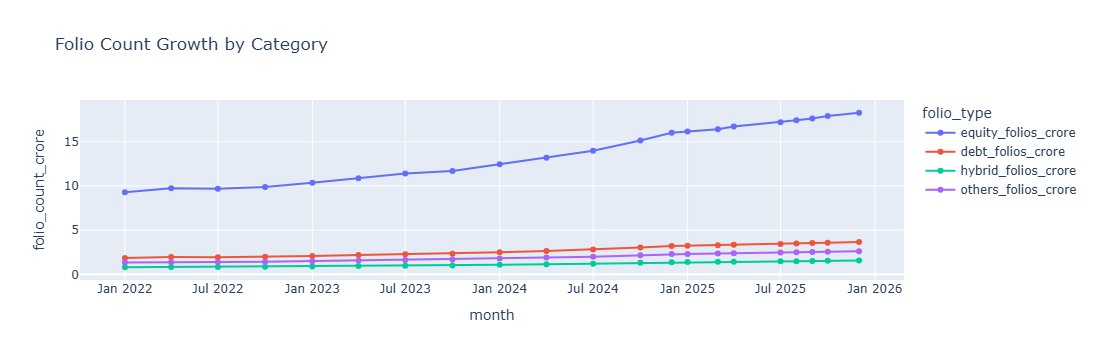

In [38]:
# Folio Category Growth
folio_long = folio.melt(
    id_vars="month",
    value_vars=[
        "equity_folios_crore",
        "debt_folios_crore",
        "hybrid_folios_crore",
        "others_folios_crore"
    ],
    var_name="folio_type",
    value_name="folio_count_crore"
)

fig = px.line(
    folio_long,
    x="month",
    y="folio_count_crore",
    color="folio_type",
    markers=True,
    title="Folio Count Growth by Category"
)

fig.show()
fig.write_html(CHART_DIR / "14_folio_category_growth.html")

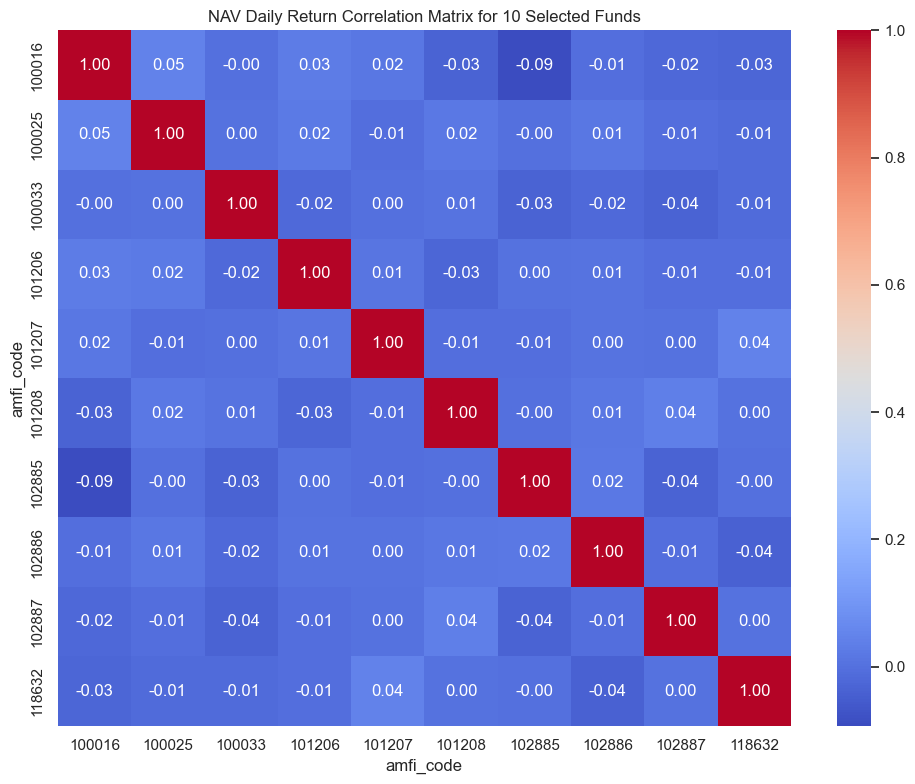

In [39]:
# NAV Return Correlation Matrix
selected_funds = nav_history["amfi_code"].unique()[:10]

nav_selected = nav_history[
    nav_history["amfi_code"].isin(selected_funds)
].copy()

nav_pivot = nav_selected.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

daily_returns = nav_pivot.pct_change().dropna()

corr_matrix = daily_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("NAV Daily Return Correlation Matrix for 10 Selected Funds")
plt.tight_layout()
plt.savefig(CHART_DIR / "15_nav_return_correlation_matrix.png", dpi=300)
plt.show()

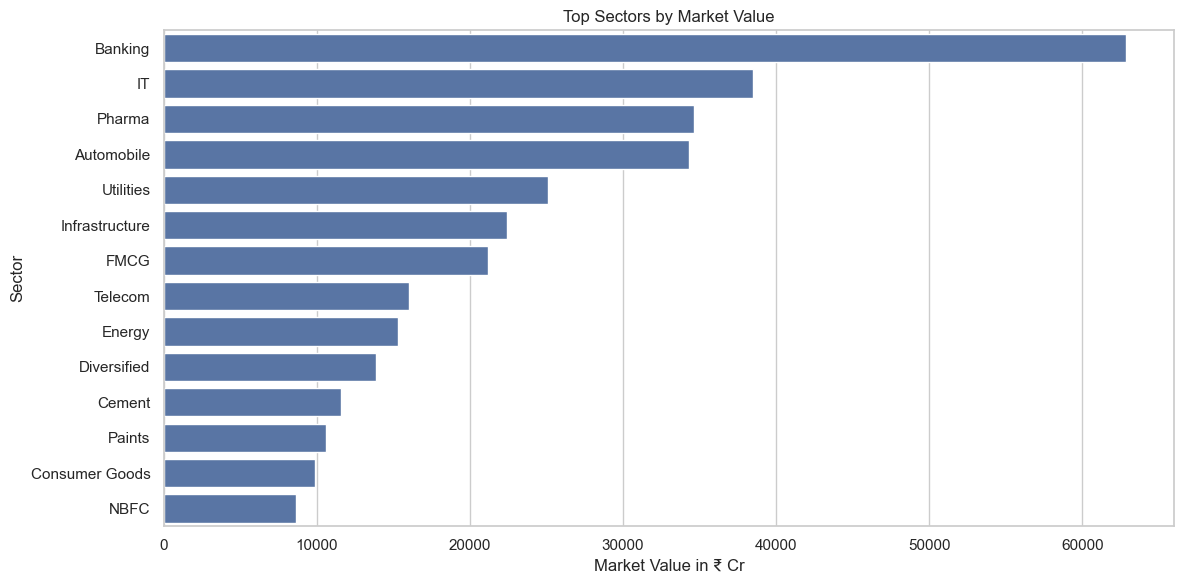

In [40]:
# Top Sectors by market value
sector_value = holdings.groupby("sector")["market_value_cr"].sum().reset_index()
sector_value = sector_value.sort_values("market_value_cr", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=sector_value,
    x="market_value_cr",
    y="sector"
)

plt.title("Top Sectors by Market Value")
plt.xlabel("Market Value in ₹ Cr")
plt.ylabel("Sector")
plt.tight_layout()
plt.savefig(CHART_DIR / "17_top_sectors_by_market_value.png", dpi=300)
plt.show()

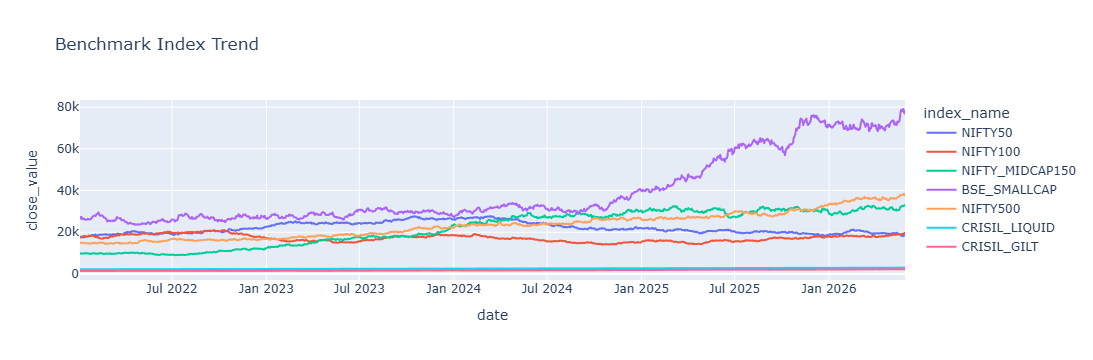

In [41]:
# Benchmark Index Trend
fig = px.line(
    benchmarks,
    x="date",
    y="close_value",
    color="index_name",
    title="Benchmark Index Trend"
)

fig.show()
fig.write_html(CHART_DIR / "18_benchmark_index_trend.html")

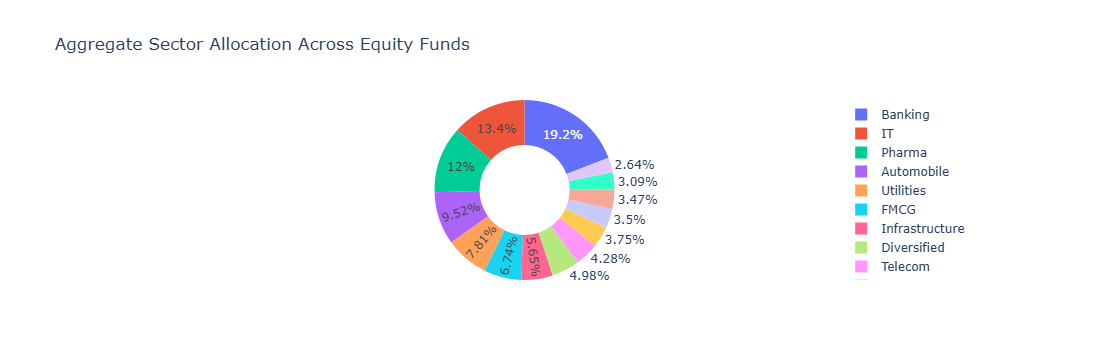

In [42]:
# Sector Allocation Donut Chart
sector_allocation = holdings.groupby("sector")["weight_pct"].sum().reset_index()

fig = px.pie(
    sector_allocation,
    names="sector",
    values="weight_pct",
    hole=0.5,
    title="Aggregate Sector Allocation Across Equity Funds"
)

fig.show()
fig.write_html(CHART_DIR / "16_sector_allocation_donut.html")

In [44]:
## Insight 1
#The NAV trend chart shows that most schemes had visible upward movement during the 2023 bull run period.

In [45]:
## Insight 2
#The 2024 correction phase created visible volatility across many schemes in the NAV trend chart.

In [46]:
## Insight 3
#SBI Mutual Fund shows strong AUM dominance among fund houses, reaching around ₹12.5 lakh crore.

In [47]:
## Insight 4
#Monthly SIP inflows show a strong long-term upward trend from 2022 to 2025.

In [48]:
## Insight 5
#SIP inflow reached the highlighted all-time high of ₹31,002 crore in December 2025.

In [49]:
## Insight 6
#Category inflow heatmap shows which mutual fund categories attracted stronger monthly net inflows.

In [50]:
## Insight 7
#Investor demographic charts show the age groups that contribute most to transaction activity.

In [51]:
## Insight 8
#SIP amount distribution differs across age groups, showing variation in investment capacity.

In [52]:
## Insight 9
#State-wise SIP chart shows geographic concentration of SIP investments.

In [53]:
## Insight 10
#Folio count increased strongly from 13.26 crore in January 2022 to 26.12 crore in December 2025.